In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

print("Notebook is ready!")

Notebook is ready!


In [2]:
from data_loader import load_data, create_target, handle_missing

# Load the data
df = load_data('../data/ADHD.xlsx')

# Create target variable
df = create_target(df)

# Handle missing values
df = handle_missing(df)

# Quick check
df[['asrs_part_a', 'target']].head(10)

Data loaded successfully — 506 rows, 110 columns
Target created — ADHD Positive: 251, Negative: 255
Missing values handled successfully


,asrs_part_a,target
0,5,0
1,14,1
2,13,0
3,15,1
4,7,0
5,11,0
6,11,0
7,6,0
8,13,0
9,16,1


In [3]:
from feature_engineering import build_feature_matrix

# Build the full feature matrix
X, vectorizer = build_feature_matrix(df)

# Get the target variable
y = df['target'].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Ready to train!")

Numeric features selected: 20
Categorical features encoded: 4
TF-IDF features created: 100 words/phrases

Final feature matrix shape: 506 rows x 124 features

X shape: (506, 124)
y shape: (506,)
Ready to train!


In [4]:
from model import split_data, train_logistic_regression, train_random_forest, save_model

# Split the data
X_train, X_test, y_train, y_test = split_data(X, y)

# Train both models
lr_model = train_logistic_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train)

# Save both models to disk
save_model(lr_model, 'logistic_regression.pkl')
save_model(rf_model, 'random_forest.pkl')

Training set : 404 rows
Testing set  : 102 rows

Training Logistic Regression...
Logistic Regression trained successfully!

Training Random Forest...
Random Forest trained successfully!
Model saved to: ../models\logistic_regression.pkl
Model saved to: ../models\random_forest.pkl



  Results for: Logistic Regression
  Accuracy  : 79.4%
  F1 Score  : 78.8%
  Precision : 81.2%
  Recall    : 76.5%

Full classification report:
               precision    recall  f1-score   support

ADHD Negative       0.78      0.82      0.80        51
ADHD Positive       0.81      0.76      0.79        51

     accuracy                           0.79       102
    macro avg       0.80      0.79      0.79       102
 weighted avg       0.80      0.79      0.79       102



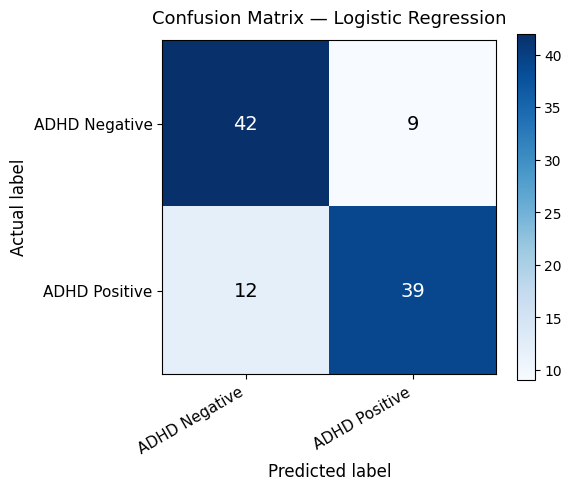

Confusion matrix saved to models/ folder

  Results for: Random Forest
  Accuracy  : 76.5%
  F1 Score  : 73.3%
  Precision : 84.6%
  Recall    : 64.7%

Full classification report:
               precision    recall  f1-score   support

ADHD Negative       0.71      0.88      0.79        51
ADHD Positive       0.85      0.65      0.73        51

     accuracy                           0.76       102
    macro avg       0.78      0.76      0.76       102
 weighted avg       0.78      0.76      0.76       102



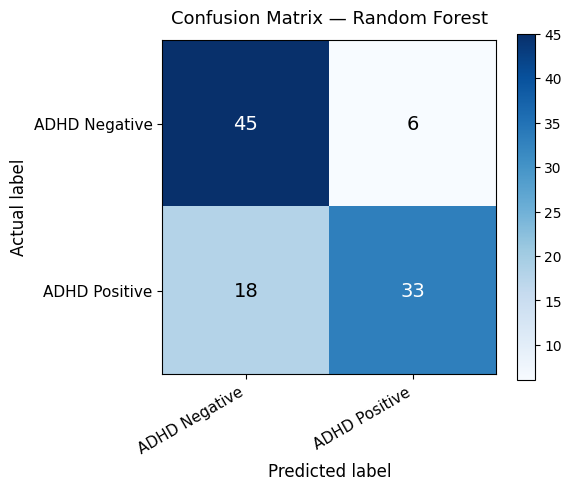

Confusion matrix saved to models/ folder


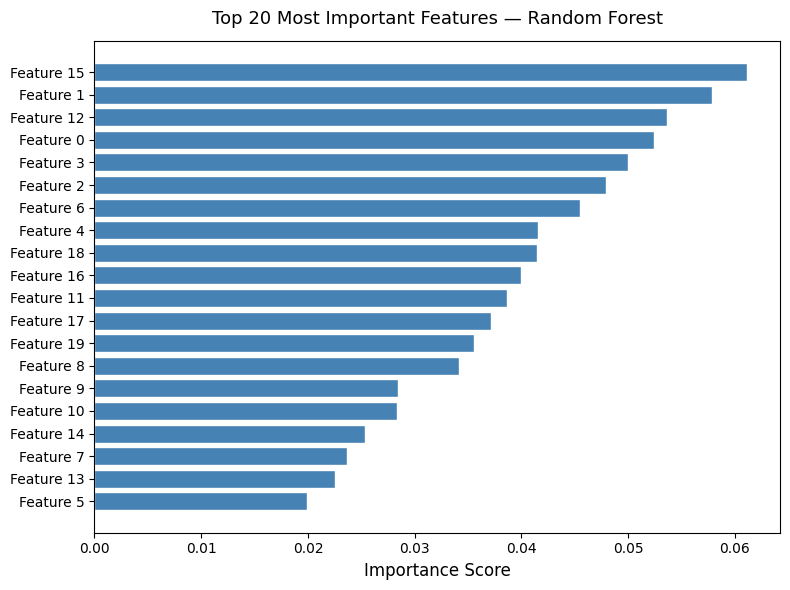

Feature importance plot saved to models/ folder

  MODEL COMPARISON SUMMARY
  Model                       Accuracy       F1   Recall
  --------------------------------------------------
  Logistic Regression            79.4%    78.8%    76.5%
  Random Forest                  76.5%    73.3%    64.7%


In [5]:
from evaluate import evaluate_model, plot_confusion_matrix, plot_feature_importance, compare_models

# Evaluate Logistic Regression
lr_preds = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
plot_confusion_matrix(y_test, lr_preds, "Logistic Regression")

# Evaluate Random Forest
rf_preds = evaluate_model(rf_model, X_test, y_test, "Random Forest")
plot_confusion_matrix(y_test, rf_preds, "Random Forest")

# Feature importance for Random Forest
plot_feature_importance(rf_model, "Random Forest", top_n=20)

# Side by side comparison
compare_models({
    "Logistic Regression": lr_model,
    "Random Forest"      : rf_model
}, X_test, y_test)

## Added: Feature Selection and Class Imbalance Handling

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# Assuming target column is 'target' (update if different)
target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col]

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Handle missing
X = X.fillna(X.mean())

# Encode target if needed
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Check imbalance
print("Class distribution before:", pd.Series(y).value_counts())

# Apply SMOTE if imbalance exists
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

print("Class distribution after:", pd.Series(y_res).value_counts())

# Feature selection
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X_res, y_res)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)


Class distribution before: target
0    255
1    251
Name: count, dtype: int64
Class distribution after: target
0    255
1    255
Name: count, dtype: int64
Selected Features: Index(['bdi1_item_19', 'bdi1_total', 'aas1_item_4', 'asrs1_item_1',
       'asrs1_item_2', 'asrs1_item_3', 'asrs1_item_4', 'asrs1_item_5',
       'asrs1_item_6', 'asrs1_item_7', 'asrs1_item_8', 'asrs1_item_9',
       'asrs1_item_10', 'asrs1_item_11', 'asrs1_item_13', 'asrs1_item_18',
       'asrs1_total.x', 'bai1_total', 'asrs1_total.y', 'asrs_part_a'],
      dtype='str')
